# Illustrate edge effects seen in CWT amplitude spectrogram

In [2]:
%load_ext autoreload
%autoreload 2

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from sys import path
path.append('../wavelet/')

import wavelet_funcs as wf


In [92]:
from scipy.signal import periodogram

In [4]:
def cosine_signal(duration, frequency, sampling_frequency, amplitude=1.0, phase=0.0):
    """
    Generate a cosine signal.

    Parameters:
        duration (float): Signal duration in seconds
        frequency (float): Frequency of the cosine in Hz
        sampling_frequency (float): Sampling frequency in Hz
        amplitude (float): Amplitude of the cosine (default=1.0)
        phase (float): Phase shift in radians (default=0.0)

    Returns:
        t (numpy.ndarray): Time vector
        x (numpy.ndarray): Cosine signal
    """
    t = np.arange(0, duration, 1 / sampling_frequency)
    x = amplitude * np.cos(2 * np.pi * frequency * t + phase)
    return t, x

### Perfect cyclic cosine

In [150]:
t,s = cosine_signal(10, 2, 100)

# ndrop = 12

# t = t[:-ndrop]
# s = s[:-ndrop]


(<Figure size 1200x700 with 2 Axes>,
 (<Axes: ylabel='Contrast (dim. less)'>,
  <Axes: xlabel='Time (s)', ylabel='Frequency (Hz)'>))

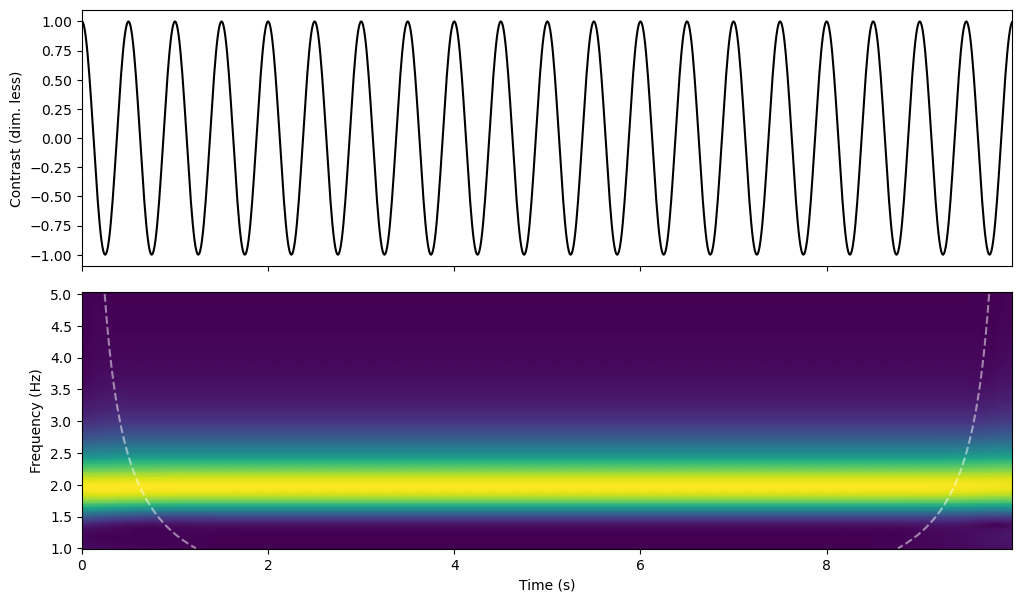

In [152]:
wf.plot_timeseries_and_its_cwt(s, t, f1=1, f2=5, method='fft', show_smoothed=False)

(0.5, 5.0)

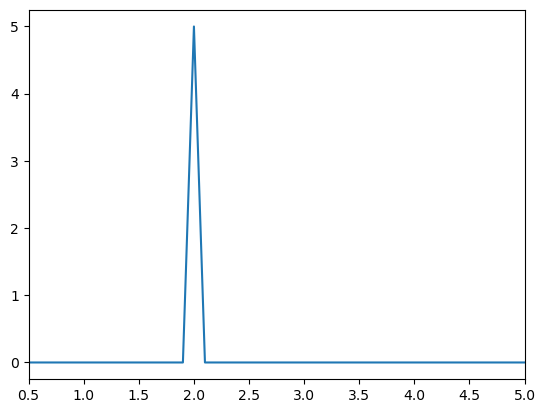

In [154]:
plt.plot(*periodogram(s, fs=100))
plt.xlim(0.5,5)

### Perfect cosine, ending not in phase

In [142]:
t,s = cosine_signal(10, 2, 100)
ndrop = 14

t = t[:-ndrop]
s = s[:-ndrop]


(<Figure size 1200x700 with 2 Axes>,
 (<Axes: ylabel='Contrast (dim. less)'>,
  <Axes: xlabel='Time (s)', ylabel='Frequency (Hz)'>))

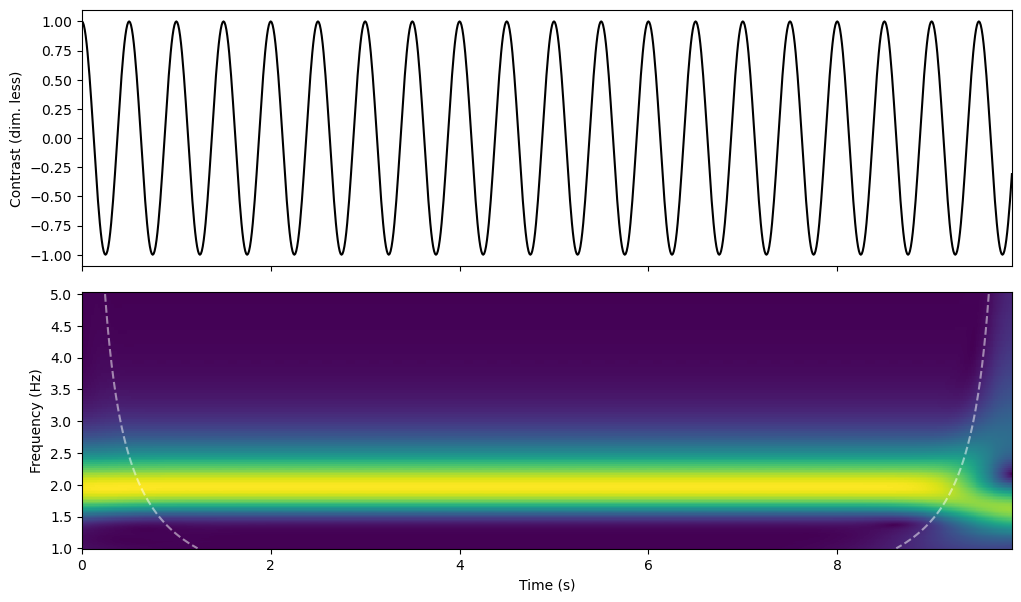

In [144]:
wf.plot_timeseries_and_its_cwt(s, t, f1=1, f2=5, method='fft', show_smoothed=False)

- Ending not in phase introduces a phase shift at the end of the time series. Padding the signal symmetrically results in splitting of the band at 2 Hz into two bands. 
- The effect is absent when the time series at the ends is in the period maximum or minimum

### Cosine with a phase shift in the middle

In [215]:
t,s = cosine_signal(10, 2, 100)
t_shift = 4

ndrop = 25
s_ = s[t>t_shift][ndrop:]
s = np.concatenate((s[t<t_shift], s_))
t = np.arange(s.size)*np.diff(t)[0]



Text(0.5, 1.0, 'Central_frequency = 1 Hz, Bandwidth=1.5 s^2')

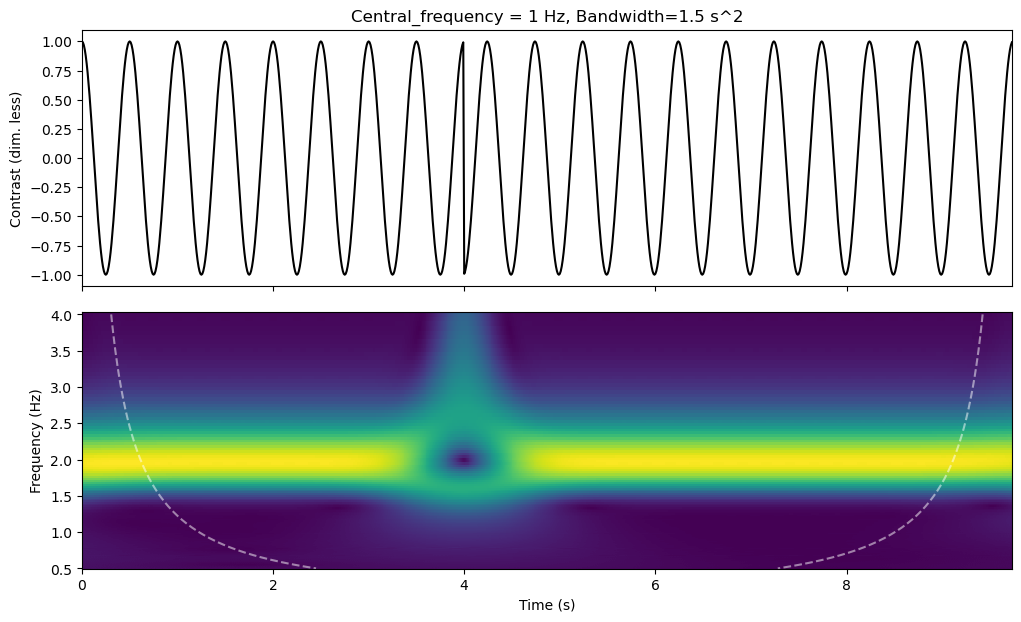

In [246]:
_, (ax, _) = wf.plot_timeseries_and_its_cwt(s, t, f1=0.5, f2=4, method='fft', central_freq=1, show_smoothed=False)
ax.set_title('Central_frequency = 1 Hz, Bandwidth=1.5 s^2')

Text(0.5, 1.0, 'Central_frequency = 2 Hz, Bandwidth=1.5 s^2')

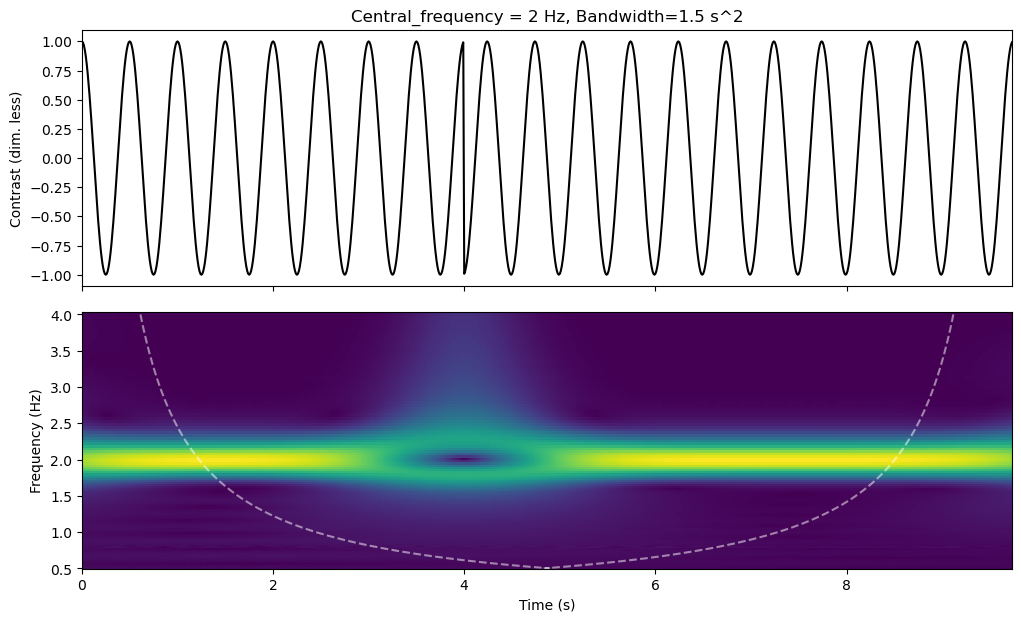

In [257]:
_, (ax, _) = wf.plot_timeseries_and_its_cwt(s, t, f1=0.5, f2=4, method='fft', central_freq=2, show_smoothed=False)
ax.set_title('Central_frequency = 2 Hz, Bandwidth=1.5 s^2')

Text(0.5, 1.0, 'Central_frequency = 1 Hz, Bandwidth=3 s^2')

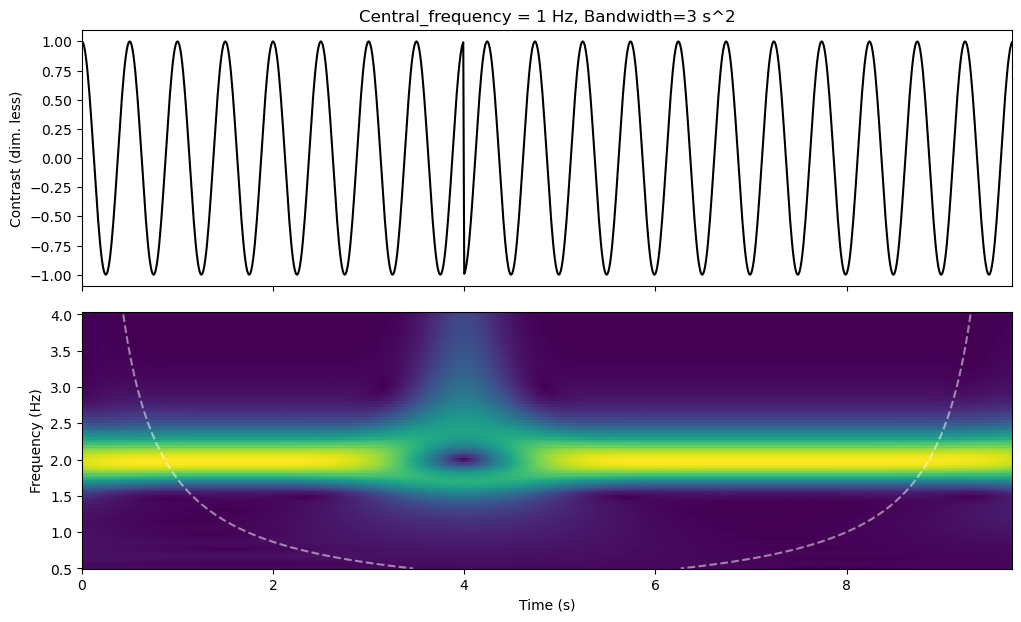

In [250]:
_, (ax, _) = wf.plot_timeseries_and_its_cwt(s, t, f1=0.5, f2=4, method='fft', bandwidth=3, show_smoothed=False)
ax.set_title('Central_frequency = 1 Hz, Bandwidth=3 s^2')

- Phase shift in the signal results in formation of "rings" interrupting the band. Rings should be an indicator of phase shifts.
- The width of the ring grows with the wavelet's central frequency and bandwidth

(0.5, 5.0)

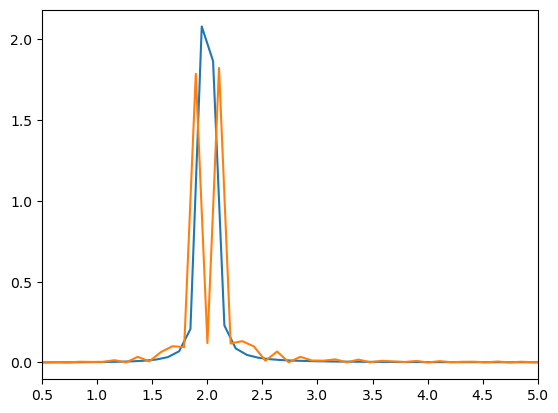

In [219]:
plt.plot(*periodogram(s, fs=100))
plt.plot(*periodogram(s[:-25], fs=100))
plt.xlim(0.5,5)

- In Fourier periodogram, such shift can show up as two closely located peaks

### Cosine with a phase shift in the middle, smoothed

In [122]:
t,s = cosine_signal(10, 2, 100)
t_shift = 5

ndrop = 25
s_ = s[t>t_shift][ndrop:]
s = np.concatenate((s[t<t_shift], s_))
t = np.arange(s.size)*np.diff(t)[0]
s = wf.gaussian_filter(s, sigma=2)


(<Figure size 1200x700 with 2 Axes>,
 (<Axes: ylabel='Contrast (dim. less)'>,
  <Axes: xlabel='Time (s)', ylabel='Frequency (Hz)'>))

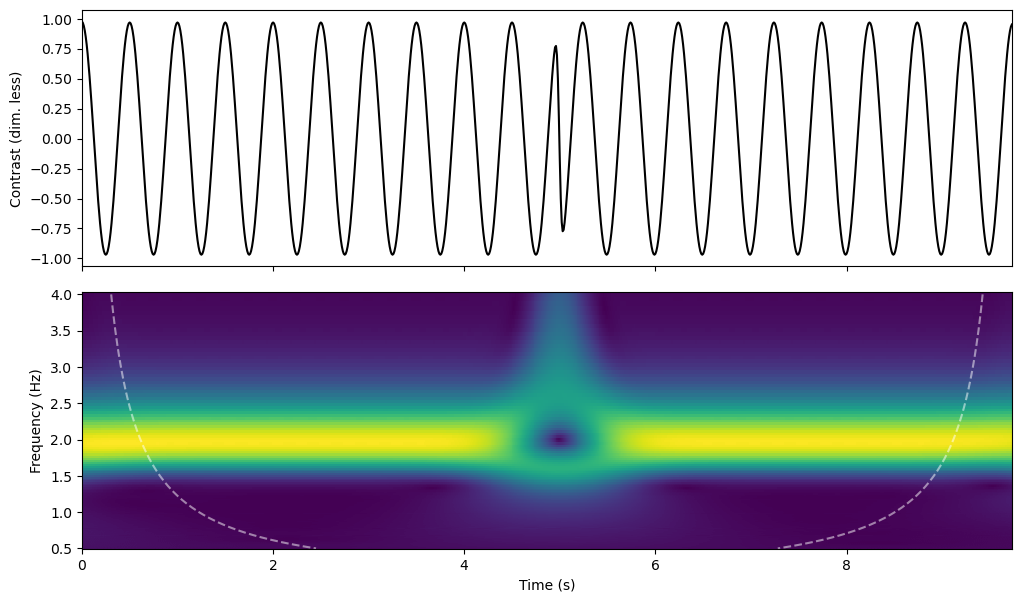

In [124]:
wf.plot_timeseries_and_its_cwt(s, t, f1=0.5, f2=4, method='fft', show_smoothed=False)
# plt.gca().set_yscale('log')

(0.5, 5.0)

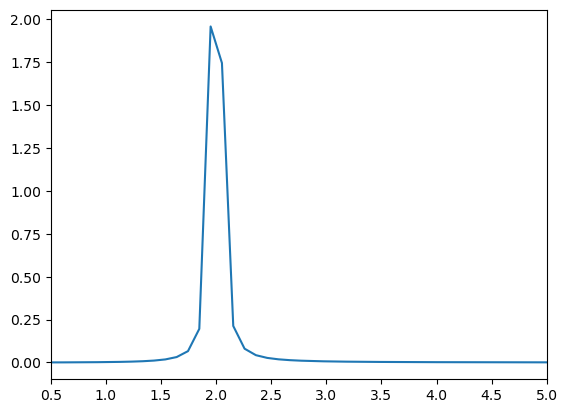

In [126]:
plt.plot(*periodogram(s, fs=100))
plt.xlim(0.5,5)